## Dataset

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.random.rand(200, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
for i in range(10):
    print(X[i], y[i])

[0.37454012 0.95071431] 1
[0.73199394 0.59865848] 1
[0.15601864 0.15599452] 0
[0.05808361 0.86617615] 0
[0.60111501 0.70807258] 1
[0.02058449 0.96990985] 0
[0.83244264 0.21233911] 1
[0.18182497 0.18340451] 0
[0.30424224 0.52475643] 0
[0.43194502 0.29122914] 0


## Trojan - Model Poisoning

In [5]:
def add_backdoor(X, y, trigger_value=0.99, target_class=0, poison_rate=0.1):
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    n_poison = int(len(X) * poison_rate)
    idx = np.random.choice(len(X), size=n_poison, replace=False)

    # aplica trigger
    X_poisoned[idx] = trigger_value

    # força label
    y_poisoned[idx] = target_class

    return X_poisoned, y_poisoned

## VQC

In [7]:
%pip install -q qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler

def create_vqc():
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    ansatz = RealAmplitudes(num_qubits=2, reps=2)
    optimizer = COBYLA(maxiter=100)

    return VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=StatevectorSampler()
    )

In [7]:
# Modelo LIMPO
vqc_clean = create_vqc()
vqc_clean.fit(X_train, y_train)

# Modelo CONTAMINADO
X_train_poisoned, y_train_poisoned = add_backdoor(X_train, y_train)

vqc_poisoned = create_vqc()
vqc_poisoned.fit(X_train_poisoned, y_train_poisoned)

C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_18196\1092618381.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_18196\1092618381.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=2)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_181

In [8]:
acc_clean = vqc_clean.score(X_test, y_test)
acc_poisoned = vqc_poisoned.score(X_test, y_test)

# ASR: pontos de teste com rotulo diferente da classe-alvo do backdoor;
# aplica-se o trigger explicito (vetor constante) e mede-se P(y_hat == alvo).
TARGET_CLASS_ASR = 0
TRIGGER_VALUE = 0.99
mask_asr = y_test != TARGET_CLASS_ASR
X_trigger_test = np.full_like(X_test[mask_asr], TRIGGER_VALUE, dtype=float)

pred_trigger_clean = vqc_clean.predict(X_trigger_test)
pred_trigger_poisoned = vqc_poisoned.predict(X_trigger_test)

asr_limpa = np.mean(pred_trigger_clean == TARGET_CLASS_ASR)
asr_contaminada = np.mean(pred_trigger_poisoned == TARGET_CLASS_ASR)

print("Acurácia modelo LIMPO:", acc_clean)
print("Acurácia modelo CONTAMINADO:", acc_poisoned)
print("ASR limpa (modelo limpo + trigger no teste):", round(asr_limpa, 4))
print("ASR contaminada (modelo contaminado + trigger no teste):", round(asr_contaminada, 4))

Acurácia modelo LIMPO: 0.875
Acurácia modelo CONTAMINADO: 0.825


## Matriz de confusão

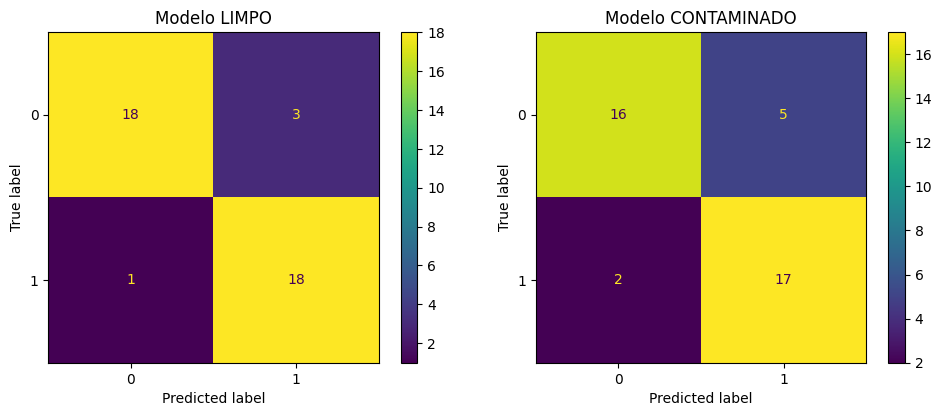

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predições
y_pred_clean = vqc_clean.predict(X_test)
y_pred_poisoned = vqc_poisoned.predict(X_test)

# Matrizes
cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_poisoned = confusion_matrix(y_test, y_pred_poisoned)

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0])
axes[0].set_title("Modelo LIMPO")

ConfusionMatrixDisplay(cm_poisoned).plot(ax=axes[1])
axes[1].set_title("Modelo CONTAMINADO")

plt.tight_layout()
plt.show()

## Fronteira de decisão

In [10]:
def plot_decision_boundary(model, X, y, title):
    import numpy as np
    import matplotlib.pyplot as plt

    # grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # predição no grid
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # plot
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()

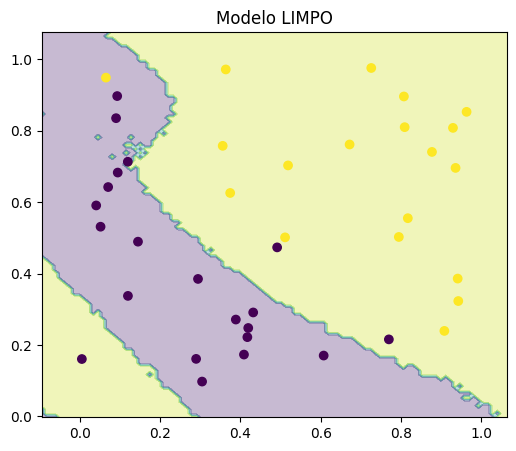

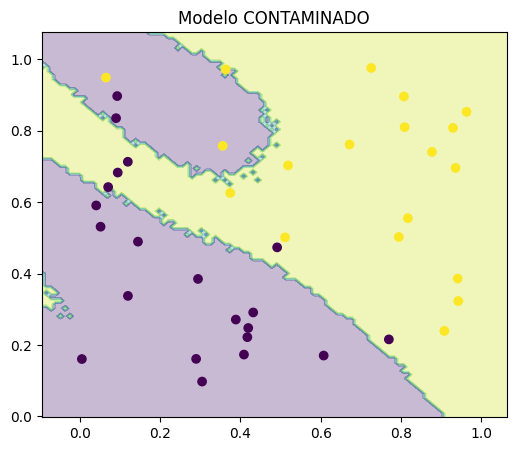

In [11]:
plot_decision_boundary(vqc_clean, X_test, y_test, "Modelo LIMPO")
plot_decision_boundary(vqc_poisoned, X_test, y_test, "Modelo CONTAMINADO")

# RECOMENDAÇÕES GPT


# 🛡️ 1. Prevenção (antes do treinamento)

## 🔍 Validação e controle de dados

O ataque que você implementou depende de **dados contaminados**.

**Defesas:**

* Auditoria da origem dos dados
* Limitar contribuições externas (crowdsourcing é um risco)
* Detectar padrões artificiais (ex: muitos pontos iguais como `[0.99, 0.99]`)

👉 Técnica simples:

```python
# detectar duplicações suspeitas
unique, counts = np.unique(X_train, axis=0, return_counts=True)
suspeitos = unique[counts > 3]
```

---

## 📊 Data sanitization (limpeza de dados)

* Remover outliers extremos
* Usar clustering para detectar pontos artificiais
* Filtrar exemplos inconsistentes

👉 No seu caso:

* o trigger é um **ponto fora da distribuição natural**

---

## 🔐 Cadeia de suprimentos confiável

Especialmente importante em **Machine Learning Quântico**:

* Garantir integridade de:

  * datasets
  * circuitos
  * bibliotecas

---

# 🚨 2. Detecção (durante ou após treinamento)

## 🎯 Testes com inputs adversariais

Simples e muito eficaz:

* Gerar inputs “suspeitos” (como seu trigger)
* Verificar se o modelo responde de forma anômala

👉 Você já fez isso — isso é **uma técnica de detecção**

---

## 📉 Análise de comportamento local

* Verificar regiões onde o modelo muda drasticamente a decisão
* Detectar “ilhas” de decisão artificial

👉 Seu gráfico de fronteira já ajuda nisso

---

## 🔍 Explainability (interpretabilidade)

Mesmo em modelos quânticos (mais difícil), pode-se tentar:

* Sensibilidade a features
* Influência de inputs específicos

👉 Ideia:

> Se um único padrão domina a decisão → possível backdoor

---

# ⚙️ 3. Mitigação (depois de detectar)

## 🧹 Re-treinamento com dados limpos

* Remover amostras suspeitas
* Re-treinar o modelo

👉 É a abordagem mais prática

---

## 🔄 Adversarial training

* Inserir exemplos com trigger **com label correto**
* Ensinar o modelo a não cair no ataque

```python
# corrigindo o trigger
X_train_fixed = np.vstack([X_train, [[0.99, 0.99]]])
y_train_fixed = np.append(y_train, [1])  # label correto
```

---

## 🧠 Regularização e robustez

* Reduzir overfitting
* Tornar o modelo menos sensível a padrões específicos

No VQC:

* reduzir profundidade do circuito
* limitar parâmetros livres

---

# ⚛️ 4. Defesas específicas para QML (diferencial)

## 🔬 Auditoria de circuitos

* Verificar se há portas ou padrões suspeitos
* Comparar circuitos antes/depois do treinamento

---

## ☁️ Execução confiável

Se usar cloud (ex: IBM):

* validar resultados com múltiplas execuções
* usar diferentes backends
* verificar consistência estatística

---

## 📊 Robustez a ruído

Curiosamente:

* o ruído quântico pode **mascarar ou reduzir** backdoors
* mas também pode **esconder ataques**

👉 Isso é um ponto interessante para discussão

---

# 🧩 Resumo estruturado (para slide)

Você pode organizar assim:

### 🔒 Prevenção

* Validação de dados
* Sanitização
* Cadeia confiável

### 🔍 Detecção

* Testes com triggers
* Análise da fronteira de decisão
* Interpretabilidade

### 🛠️ Mitigação

* Re-treinamento
* Adversarial training
* Regularização
